# Task 5 — Sales Prediction Using Python

## Objective
Build regression models to predict product sales from advertising spend across **TV, Radio, and Newspaper** channels.


## Models
1. Linear Regression — baseline
2. Random Forest Regressor — additional model




 ## Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv(
    "Advertising Budget and Sales.csv",
    encoding="utf-8-sig"
)

# Data Cleaning

In [ ]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
# remove index column
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df.shape

(200, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df.isnull().sum()

,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
TV Ad Budget ($),float64
Radio Ad Budget ($),float64
Newspaper Ad Budget ($),float64
Sales ($),float64


In [ ]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
# check negative value in columns
(df < 0).sum()

,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


# Exploratory Data Analysis (EDA)
..Pairplot of All Features

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

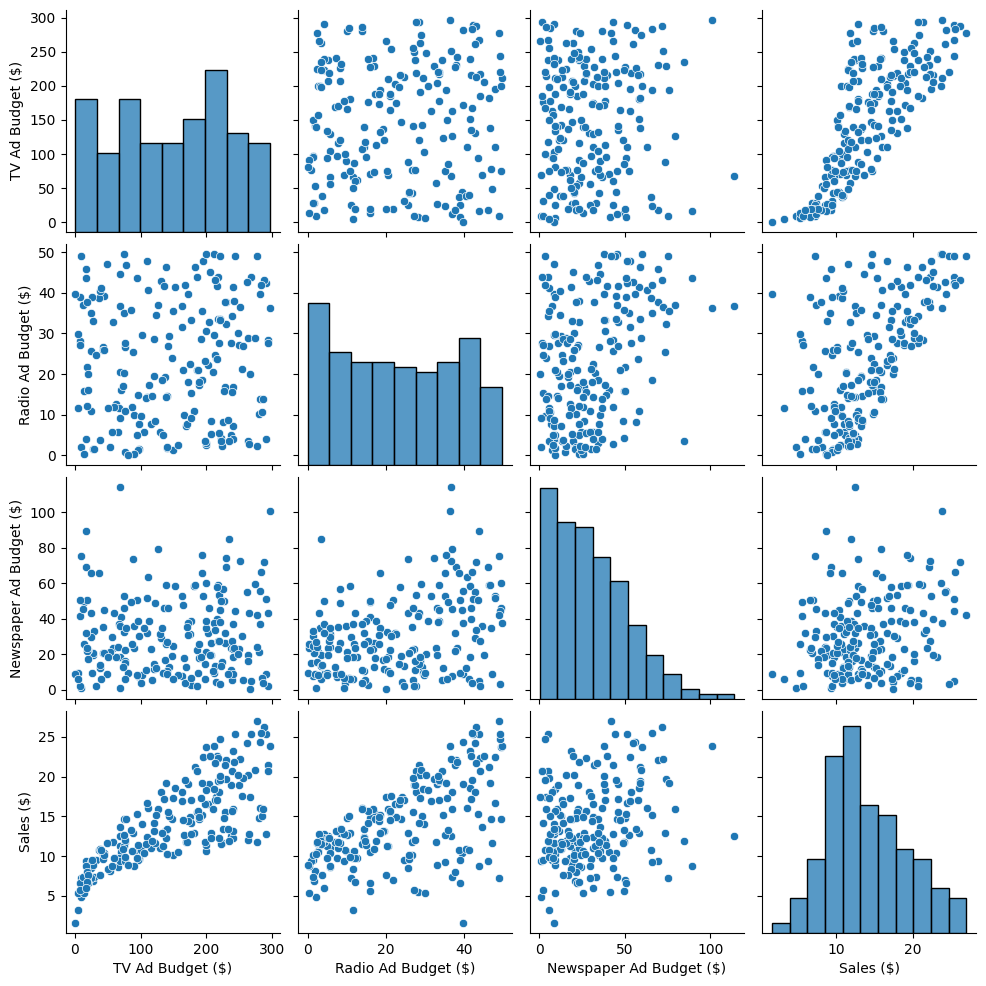

In [ ]:
sns.pairplot(
    df,
    diag_kind="hist",
    corner=False
)

plt.show()

..TV vs Sales Plot





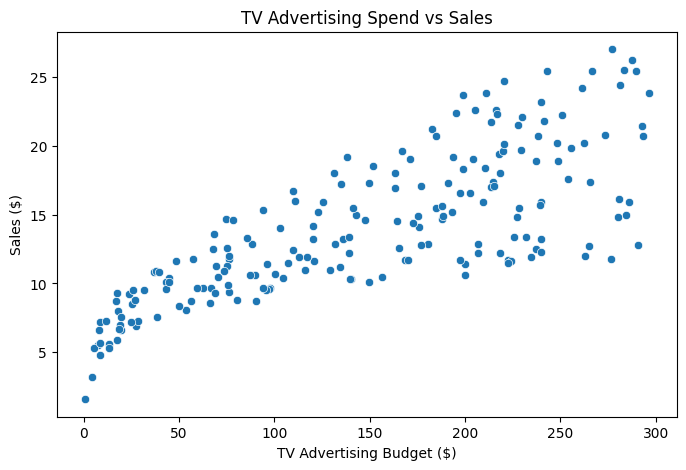

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV Ad Budget ($)",
    y="Sales ($)"
)

plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

.. Radio Vs Sale Plot

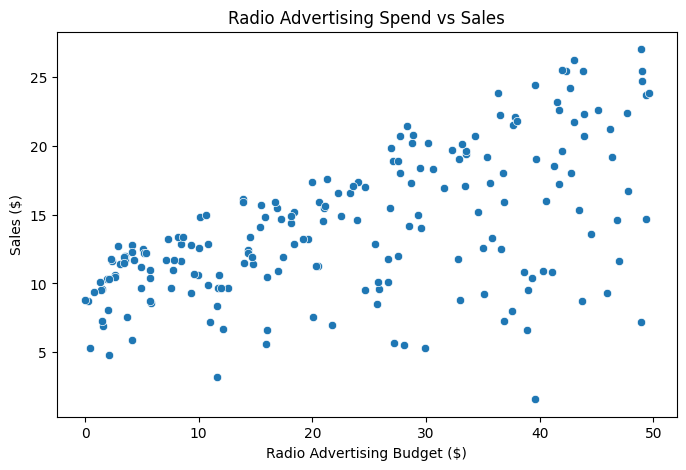

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Radio Ad Budget ($)",
    y="Sales ($)"
)

plt.title("Radio Advertising Spend vs Sales")
plt.xlabel("Radio Advertising Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

..Newspaper vs Sales Plot

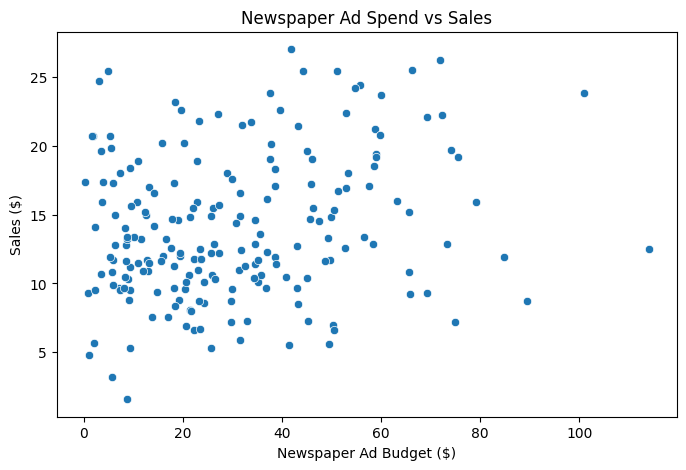

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Newspaper Ad Budget ($)",
    y="Sales ($)"
)

plt.title("Newspaper Ad Spend vs Sales")
plt.xlabel("Newspaper Ad Budget ($)")
plt.ylabel("Sales ($)")

plt.show()

# Correlation matrix heatmap

In [ ]:
correlation = df.corr()

correlation

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
TV Ad Budget ($),1.000000,0.054809,0.056648,0.782224
Radio Ad Budget ($),0.054809,1.000000,0.354104,0.576223
Newspaper Ad Budget ($),0.056648,0.354104,1.000000,0.228299
Sales ($),0.782224,0.576223,0.228299,1.000000


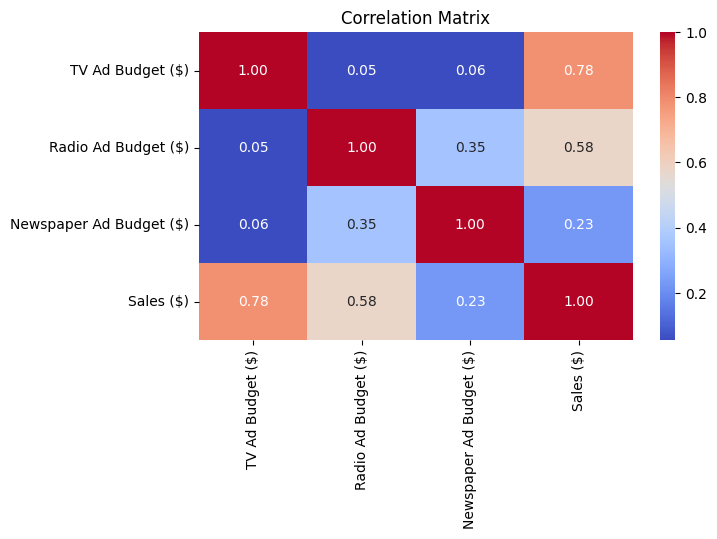

In [ ]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Train/Test Split
.. Check outliers

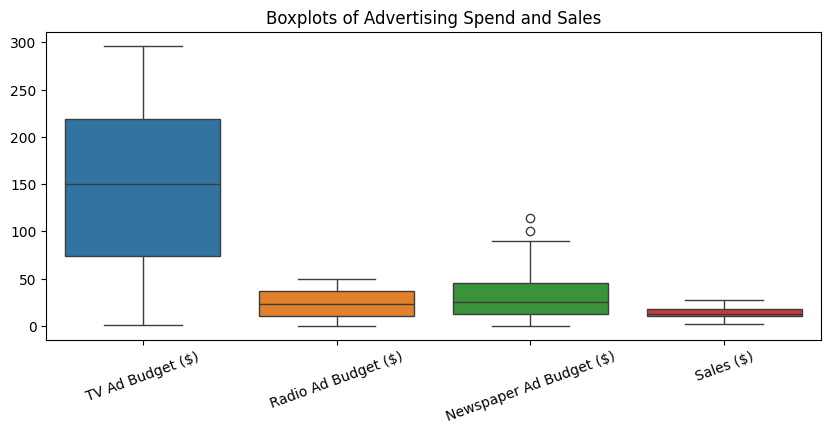

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df)

plt.title("Boxplots of Advertising Spend and Sales")
plt.xticks(rotation=20)

plt.show()

..Define X and y

In [ ]:
X = df[[
    "TV Ad Budget ($)",
    "Radio Ad Budget ($)",
    "Newspaper Ad Budget ($)"
]]

y = df["Sales ($)"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


.. Split the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
# create the model
lr_model = LinearRegression()
# train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# check predictions
y_pred_lr = lr_model.predict(X_test)
# comparison between actual and predicted sales
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_lr
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


# Evaluate Linear Regression

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np


In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Results
-------------------------
MAE  : 1.4608
RMSE : 1.7816
R²   : 0.8994


..Linear Regression Coefficients

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,TV Ad Budget ($),0.044730
1,Radio Ad Budget ($),0.189195
2,Newspaper Ad Budget ($),0.002761


..Visualize Actual vs Predicted Sales

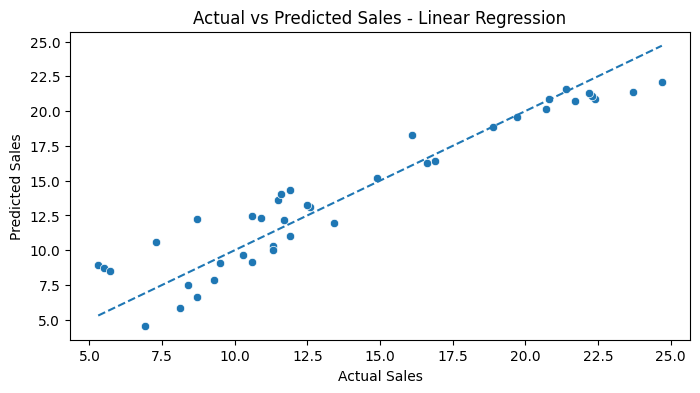

In [ ]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Linear Regression")

plt.show()

# 2nd Model
# Random Forest Regressor.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
# train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
#predict the model
y_pred_rf = rf_model.predict(X_test)

..Evaluate Random Forest

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
---------------------
MAE  : 0.6287
RMSE : 0.7572
R²   : 0.9818


# Compare Both Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R²": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


# Residual Analysis
..Residual plot for the best model

In [ ]:
residuals = y_test - y_pred_rf

In [ ]:
residuals.head()

,Sales ($)
95,-0.8615
15,0.7335
30,0.7405
158,0.5605
128,1.6040


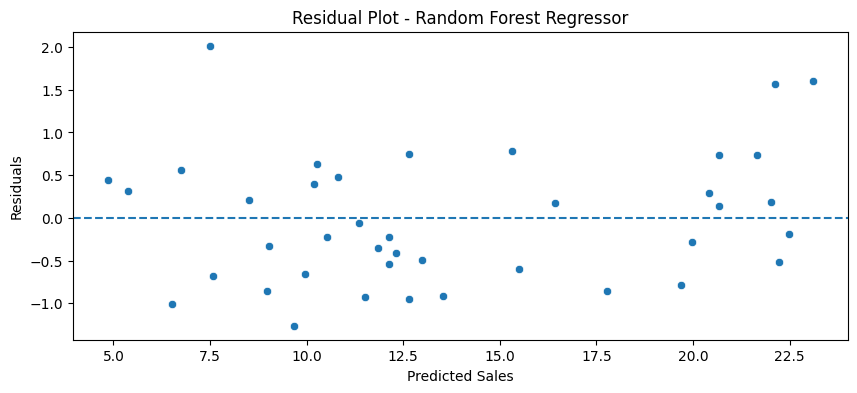

In [ ]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")

plt.show()

# Which advertising channel has the highest impact on sales?

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV Ad Budget ($),0.624727
1,Radio Ad Budget ($),0.362119
2,Newspaper Ad Budget ($),0.013153


Visualize highest impact channel

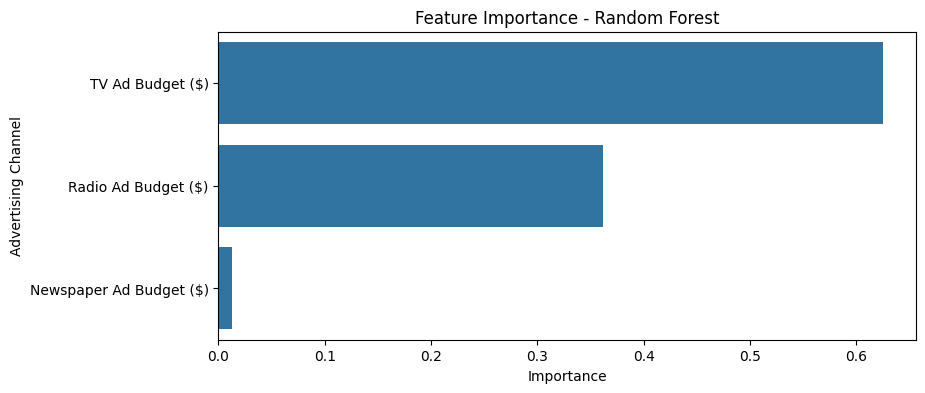

In [ ]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

#Interpretation: which advertising channel has the highest impact on sales?

In [ ]:
most_important = feature_importance.iloc[0]

print(
    f"The advertising channel with the highest impact on sales is "
    f"{most_important['Feature']} "
    f"with an importance of {most_important['Importance']:.4f}."
)

The advertising channel with the highest impact on sales is TV Ad Budget ($) with an importance of 0.6247.


**Observation:**

Two regression models, Linear Regression and Random Forest Regressor, were developed to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels. Linear Regression achieved an R² score of 0.8994, while Random Forest achieved a substantially higher R² score of 0.9818. Random Forest also produced lower MAE and RMSE values, indicating more accurate predictions.

Based on the model comparison, Random Forest was selected as the best-performing model. Feature importance analysis showed that TV advertising was the most important predictor of sales, with an importance of 0.6247, followed by Radio at 0.3621. Newspaper had a relatively small importance of 0.0132.

Overall, the results suggest that TV and Radio advertising expenditure are the strongest predictive factors for sales in this dataset. The Random Forest model can therefore be used to estimate expected sales based on advertising budgets across these channels.

### Residual Interpretation

The residual plot should be checked for a random spread around zero. A roughly random pattern suggests that the model errors do not show a strong systematic trend. A clear curve, funnel shape, or other pattern can indicate that the model is missing structure in the data.


# Final Interpretation

- Compare Linear Regression and Random Forest using **MAE, RMSE, and R²**.
- The best model should have lower MAE/RMSE and higher R².
- For the Random Forest, use `feature_importances_` to identify which advertising channel has the highest predictive importance.
- For Linear Regression, the coefficients describe the estimated change in sales for a one-unit increase in each advertising channel while holding the other features constant.
